In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

# Q1: Which symptoms are most strongly associated with diabetes, and why might these relationships exist?

In [3]:
df = pd.read_csv("../files/early_diabetes_data_cleaned.csv")

target = df['class']
features = df.drop('class', axis = 1).copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 42)

In [4]:
rfc = RandomForestClassifier(random_state = 42)

param_grid = {
    'max_depth': [None,3, 5, 7, 10],
    'n_estimators': [50, 100, 150, 200,500],
}

gcv = GridSearchCV(rfc, param_grid = param_grid)
gcv.fit(X_train, y_train)

opt_rfc = gcv.best_estimator_
opt_rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [5]:
# Predictions
y_pred_proba = opt_rfc.predict_proba(X_test)
y_pred = opt_rfc.predict(X_test)

# Metric : Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Metric : AUC score
roc_auc = roc_auc_score(y_test, y_pred)

# Rates
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[33  0]
 [ 1 70]]


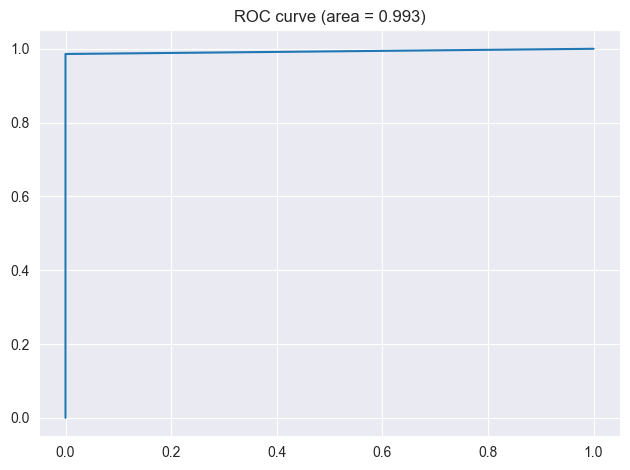

In [6]:
fig = plt.subplot()

fig.plot(fpr,tpr)
plt.title(f"ROC curve (area = {round(roc_auc, 4)})")
plt.tight_layout()
plt.show()

In [7]:
importances = opt_rfc.feature_importances_

frame = {
    'importances':importances,
    'factors': X_test.columns
}
feat_importance = pd.DataFrame(frame,
                            columns=list(frame.keys()))
feat_importance = feat_importance.sort_values(by=['importances'],ascending=False)
feat_importance.index = [i for i in range(1,len(feat_importance.index)+1)]

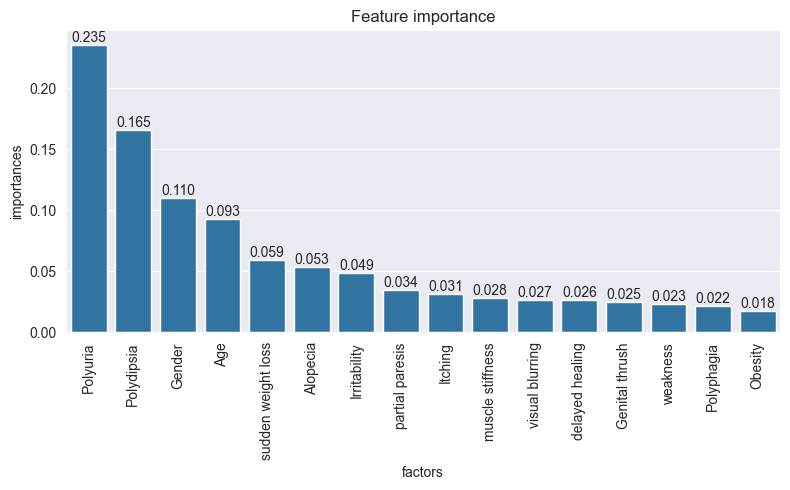

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
ax = sns.barplot(feat_importance,y = 'importances',x='factors')

# labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

ax.set_xticks(feat_importance['factors'])
ax.set_xticklabels(labels=feat_importance['factors'],rotation=90)
plt.title("Feature importance")
plt.tight_layout()

In [61]:
df["age_group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"]
)

cat_features = df.drop(columns=['Age', 'age_group']).copy()
age = df['Age'].copy()
# target = df['class'].copy()

cat_features = np.transpose(cat_features.groupby('class').mean())
cat_features.columns = ['Negative', 'Positive']
cat_features['Diff'] = cat_features['Positive'] - cat_features['Negative']
cat_features.sort_values(by='Diff', ascending=False, inplace=True)
cat_features['Factors'] = cat_features.index
cat_features.reset_index(drop=True, inplace=True)
cat_features

,Negative,Positive,Diff,Factors
0,0.075,0.759375,0.684375,Polyuria
1,0.040,0.703125,0.663125,Polydipsia
2,0.095,0.540625,0.445625,Gender
3,0.145,0.587500,0.442500,sudden weight loss
4,0.160,0.600000,0.440000,partial paresis
5,0.240,0.590625,0.350625,Polyphagia
6,0.080,0.343750,0.263750,Irritability
7,0.290,0.546875,0.256875,visual blurring
8,0.435,0.681250,0.246250,weakness
9,0.300,0.421875,0.121875,muscle stiffness


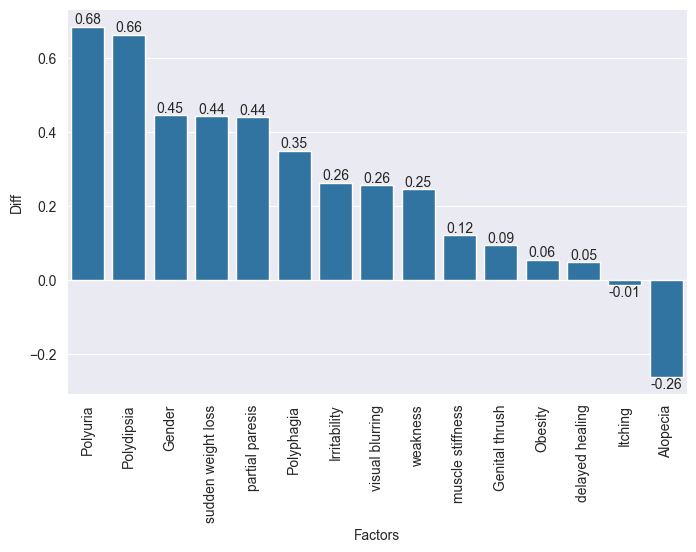

In [65]:
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=cat_features, x='Factors', y='Diff', ax=ax)
ax.tick_params(axis='x', rotation=90)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')